In [1]:

!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install streamlit
!pip install nltk spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 6.7 MB/s eta 0:00:02
     -------- ------------------------------- 2.6/12.8 MB 6.6 MB/s eta 0:00:02
     ------------ --------------------------- 3.9/12.8 MB 6.5 MB/s eta 0:00:02
     ---------------- ----------------------- 5.2/12.8 MB 6.5 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 6.5 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 6.4 MB/s eta 0:00:01
     ---------------------------- ----------- 9.2/12.8 MB 6.5 MB/s eta 0:00:01
     --------------------------------- ------ 10.7/12.8 MB 6.5 MB/s eta 0:00:01
     ------------------------------------- -- 12.1/12.8 MB 6.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.4 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\RATHIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RATHIKA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
import pandas as pd

df = pd.read_csv('data/IMDB Dataset.csv')
print(df.head())
print(df['sentiment'].value_counts())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
positive    25000
negative    25000
Name: sentiment, dtype: int64


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [6]:
!pip install wordcloud

C:\Users\RATHIKA\AppData\Local\Temp\ipykernel_17656\1847234983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


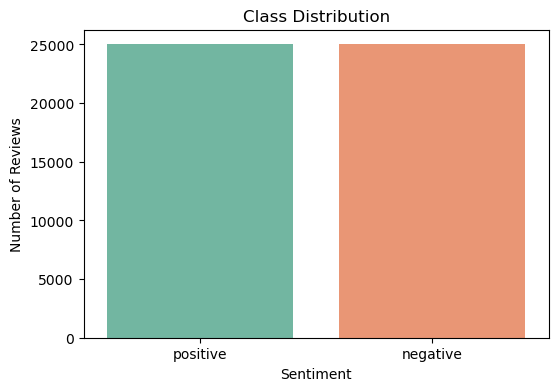

positive    25000
negative    25000
Name: sentiment, dtype: int64
positive    50.0
negative    50.0
Name: sentiment, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# Also print exact numbers
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts(normalize=True) * 100)  # as percentages

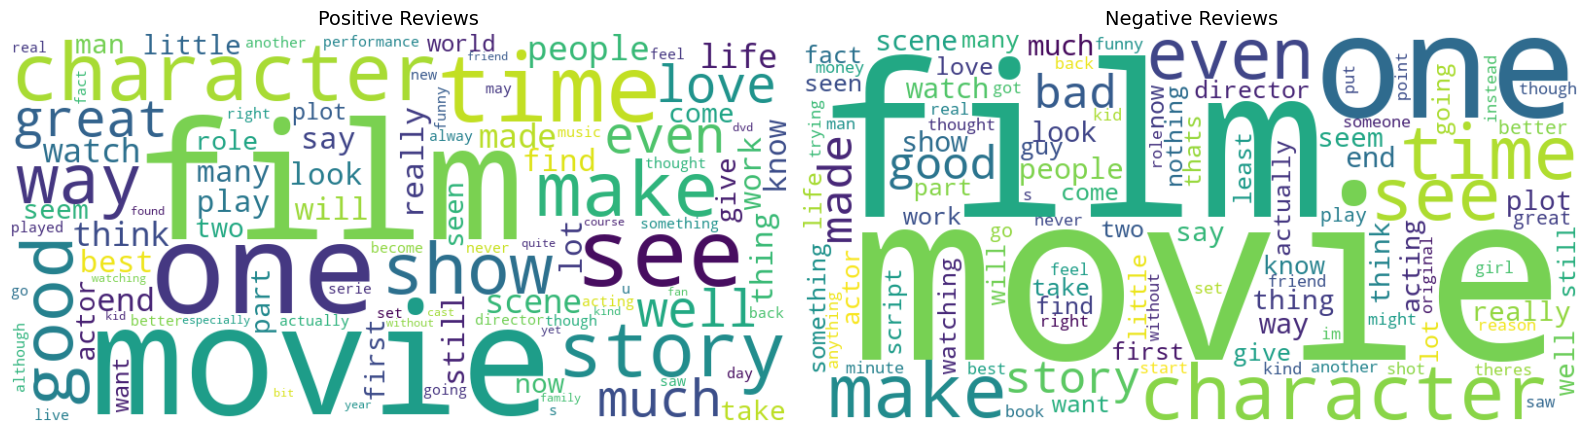

In [8]:
from wordcloud import WordCloud
import re

def clean_text(text):
    text = re.sub(r'<br\s*/?>', ' ', text)   # remove IMDB's <br /> tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove punctuation/numbers
    return text.lower()

df['clean_review'] = df['review'].apply(clean_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sentiment in zip(axes, ['positive', 'negative']):
    text = ' '.join(df[df['sentiment'] == sentiment]['clean_review'])
    wc = WordCloud(width=800, height=400, background_color='white',
                    stopwords=None, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

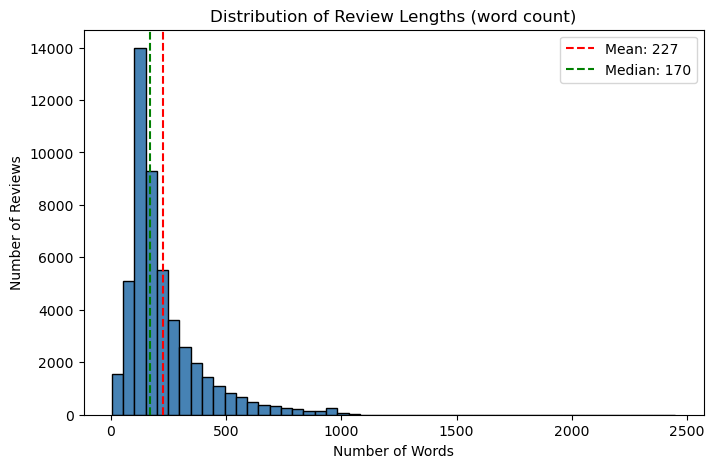

count    50000.000000
mean       226.852700
std        168.178261
min          4.000000
25%        124.000000
50%        170.000000
75%        275.000000
max       2450.000000
Name: review_length, dtype: float64


In [9]:
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
plt.hist(df['review_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Review Lengths (word count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['review_length'].mean():.0f}")
plt.axvline(df['review_length'].median(), color='green', linestyle='--', label=f"Median: {df['review_length'].median():.0f}")
plt.legend()
plt.savefig('eda_class_distribution.png')
plt.show()

print(df['review_length'].describe())

In [10]:
df['review_length'].quantile(0.95)

579.0

In [11]:
!pip install tensorflow

In [12]:
import sys

sys.path.append('src')      # if notebook is in the project root, same level as src/


from preprocess import remove_stopwords, tokenize_and_pad
from sklearn.model_selection import train_test_split

# Encode labels
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

# Stopword removal — LSTM path only
df['review_lstm'] = df['clean_review'].apply(remove_stopwords)

# BERT path keeps stopwords — just reuse clean_review as-is
df['review_bert'] = df['clean_review']

# Train/test split (do this BEFORE tokenizing, always)
X_train, X_test, y_train, y_test = train_test_split(
    df['review_lstm'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# Tokenize + pad
X_train_pad, X_test_pad, tokenizer = tokenize_and_pad(X_train, X_test)

print(X_train_pad.shape, X_test_pad.shape)


(40000, 200) (10000, 200)


In [13]:


X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    df['review_bert'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

print(X_train_bert.shape, X_test_bert.shape)

(40000,) (10000,)


In [28]:
import tensorflow as tf

BATCH_SIZE = 32
BUFFER_SIZE = 10000

train_ds = tf.data.Dataset.from_tensor_slices((X_train_pad, y_train.values))
train_ds = train_ds.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test_pad, y_test.values))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [30]:
from tensorflow.keras import layers, Sequential

vocab_size = 10000
embedding_dim = 128
max_len = 300  # matches what you used in tokenize_and_pad

model = Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_length=max_len),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # binary: positive/negative
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\RATHIKA\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model = Sequential([
    layers.Embedding(vocab_size, embedding_dim, input_shape=(max_len,)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()   # ← call it here, right after compile — should now show real params

C:\Users\RATHIKA\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\layers\core\embedding.py:126: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 300, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 300, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/10


C:\Users\RATHIKA\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 236s 184ms/step - accuracy: 0.8139 - loss: 0.4193 - val_accuracy: 0.8663 - val_loss: 0.3389
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 236s 188ms/step - accuracy: 0.8949 - loss: 0.2756 - val_accuracy: 0.8873 - val_loss: 0.2881
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 249s 199ms/step - accuracy: 0.9233 - loss: 0.2125 - val_accuracy: 0.8822 - val_loss: 0.3477
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 245s 196ms/step - accuracy: 0.9426 - loss: 0.1651 - val_accuracy: 0.8751 - val_loss: 0.3495
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 234s 188ms/step - accuracy: 0.9591 - loss: 0.1253 - val_accuracy: 0.8720 - val_loss: 0.3844


In [36]:
import os, pickle
os.makedirs('models/lstm_sentiment', exist_ok=True)
model.save('models/lstm_sentiment/lstm_model.keras')
with open('models/lstm_sentiment/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [38]:
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs = model.predict(test_ds)
y_pred_lstm = (y_pred_probs > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred_lstm, target_names=['negative', 'positive']))

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step
              precision    recall  f1-score   support

    negative       0.91      0.86      0.88      5000
    positive       0.87      0.91      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [44]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer_bert = AutoTokenizer.from_pretrained('models/bert_sentiment')
bert_model = AutoModelForSequenceClassification.from_pretrained('models/bert_sentiment')

print("Loaded successfully")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded successfully


In [46]:
import torch

text = "This movie was absolutely wonderful, I loved every minute of it!"
inputs = tokenizer_bert(text, return_tensors="pt", truncation=True, padding=True, max_length=256)

with torch.no_grad():
    outputs = bert_model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()

print("Positive" if pred == 1 else "Negative")

Positive
